### Step 1: Import Required Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Forecasting model
from statsmodels.tsa.arima.model import ARIMA

# Model evaluation
from sklearn.metrics import mean_squared_error

### Step 2: Load Dataset

In [2]:
df = pd.read_csv("PJME_hourly.csv")

In [3]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Datetime', 'PJME_MW']


In [4]:
# Display first 5 rows
print(df.head())

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0


### Step 3: Check Dataset Information

In [5]:
# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None
Datetime    0
PJME_MW     0
dtype: int64


### Step 4: Convert Datetime Column

In [6]:
# Convert Datetime column into datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set Datetime as index
df.set_index('Datetime', inplace=True)

# Sort data by date
df = df.sort_index()

print(df.head())

                     PJME_MW
Datetime                    
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0


### Step 5: Plot Original Time Series

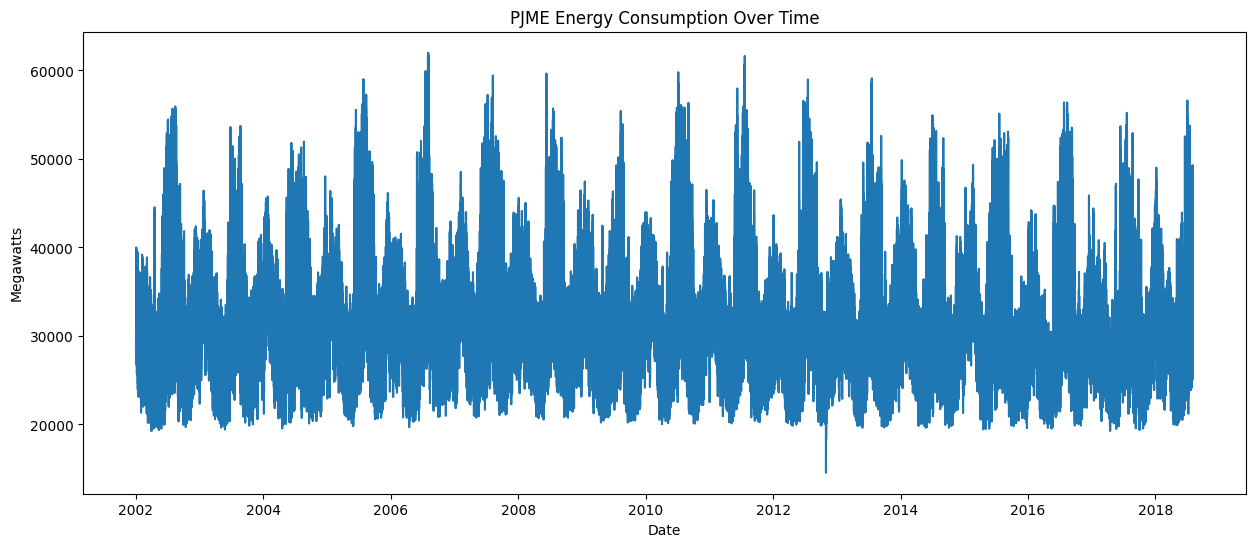

In [7]:
plt.figure(figsize=(15,6))

plt.plot(df['PJME_MW'])

plt.title("PJME Energy Consumption Over Time")

plt.xlabel("Date")
plt.ylabel("Megawatts")

plt.show()

### Step 6: Resampling Data

In [8]:
# Daily average power usage
daily = df.resample('D').mean()   # D -> daily

print(daily.head())

                 PJME_MW
Datetime                
2002-01-01  31080.739130
2002-01-02  34261.541667
2002-01-03  34511.875000
2002-01-04  33715.458333
2002-01-05  30405.125000


### Step 7: Monthly Resampling

In [9]:
# Monthly average
monthly = df.resample('ME').mean()

print(monthly.head())

                 PJME_MW
Datetime                
2002-01-31  31075.399731
2002-02-28  30239.166667
2002-03-31  28875.256720
2002-04-30  28534.731572
2002-05-31  28073.653226


### Step 8: Plot Daily Data

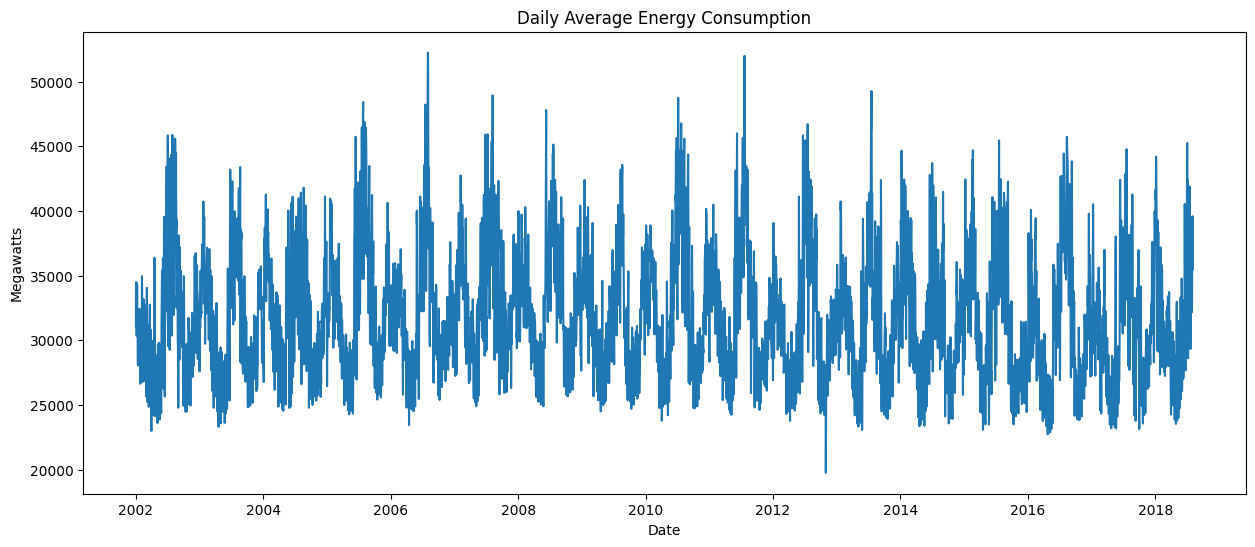

In [10]:
plt.figure(figsize=(15,6))

plt.plot(daily['PJME_MW'])

plt.title("Daily Average Energy Consumption")

plt.xlabel("Date")
plt.ylabel("Megawatts")

plt.show()

### Step 9: Decompose Time Series

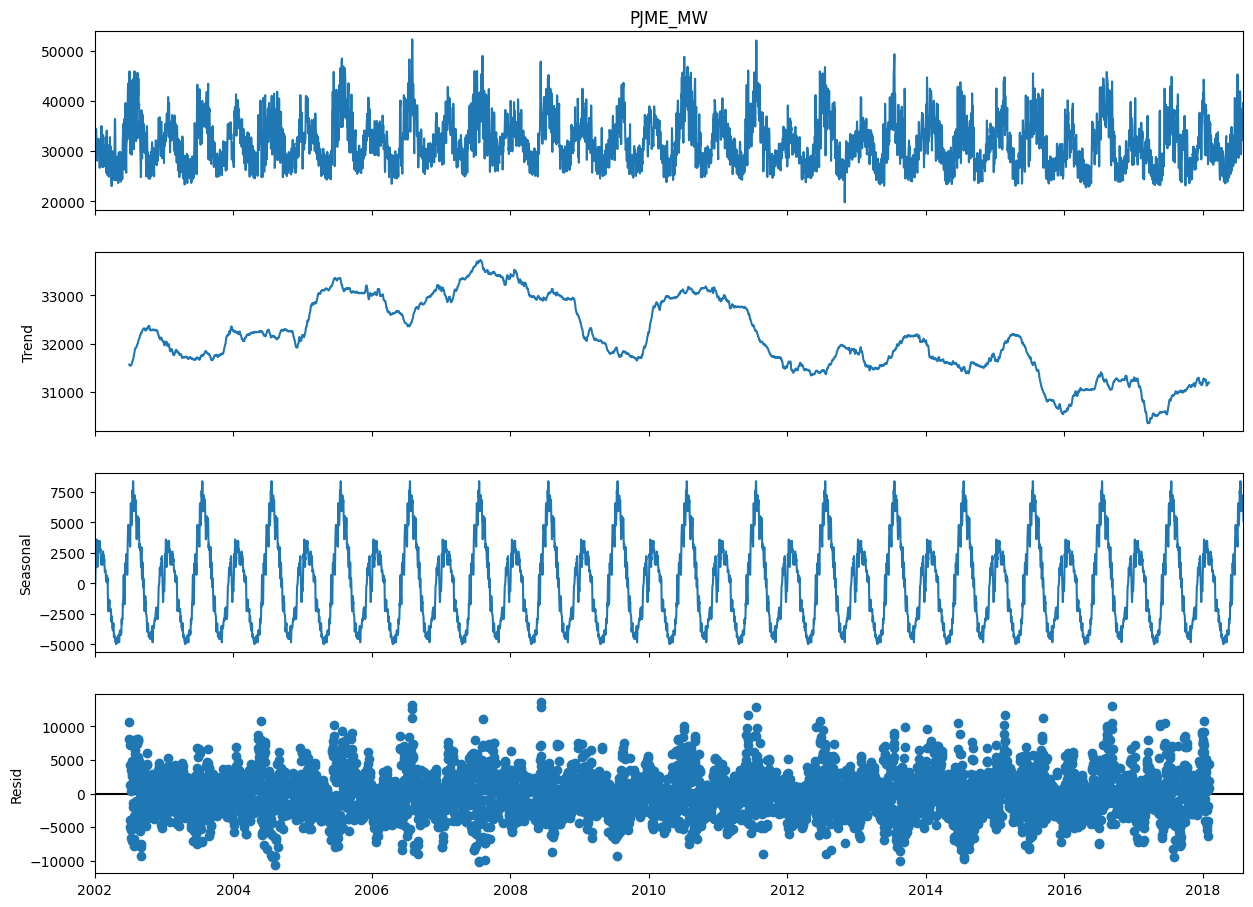

In [11]:
# Decompose data
decomposition = seasonal_decompose(
    daily['PJME_MW'],
    model='additive',
    period=365
)

# Plot decomposition
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

### Step 10: Moving Averages

In [12]:
# 7-day moving average
daily['MA_7'] = daily['PJME_MW'].rolling(window=7).mean()

# 30-day moving average
daily['MA_30'] = daily['PJME_MW'].rolling(window=30).mean()

### Step 11: Plot Moving Averages

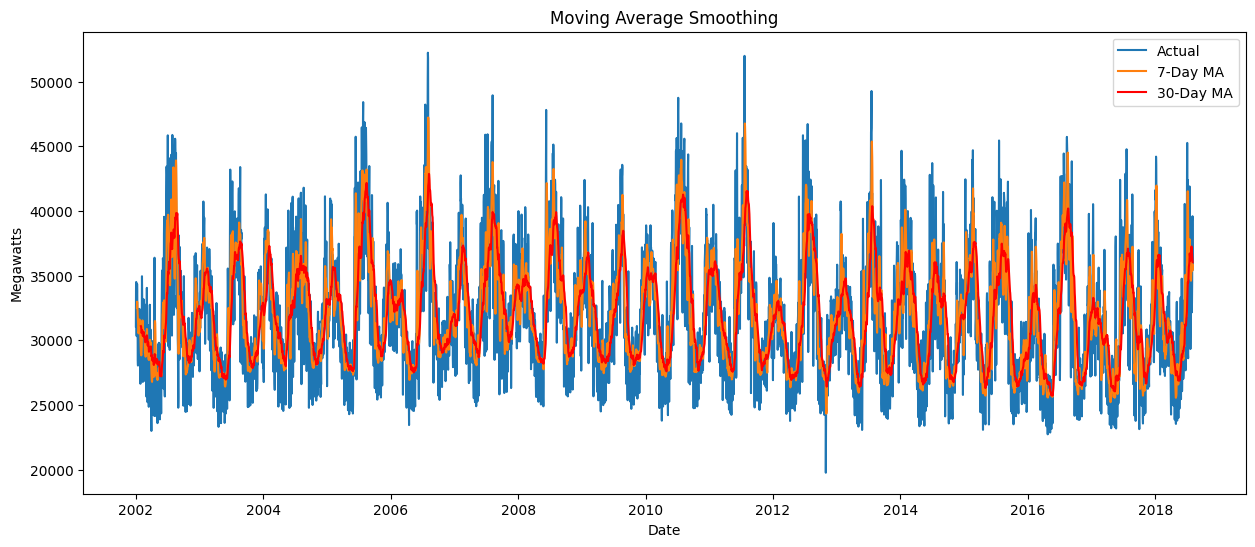

In [13]:
plt.figure(figsize=(15,6))

# Original data
plt.plot(daily['PJME_MW'],
         label='Actual')

# 7-day moving average
plt.plot(daily['MA_7'],
         label='7-Day MA')

# 30-day moving average
plt.plot(daily['MA_30'],
         label='30-Day MA',
         color='red')

plt.title("Moving Average Smoothing")

plt.xlabel("Date")
plt.ylabel("Megawatts")

plt.legend()

plt.show()

### Step 12: Train-Test Split

In [14]:
# Training data
train = daily['PJME_MW'].iloc[:-30]

# Testing data
test = daily['PJME_MW'].iloc[-30:]

### Step 13: Build ARIMA Model

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMAX model
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [16]:
# Train model
result = model.fit(maxiter=200)

In [17]:
# Print summary
print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           PJME_MW   No. Observations:                 6029
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -53683.329
Date:                           Sat, 06 Jun 2026   AIC                         107376.657
Time:                                   13:01:21   BIC                         107410.165
Sample:                               01-01-2002   HQIC                        107388.292
                                    - 07-04-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2858      0.032     -8.941      0.000      -0.348      -0.223
ma.L1          0.5587      0.029     19.601

### Step 14: Forecast Future Values

In [18]:
# Forecast next 30 days
forecast = result.forecast(steps=30)

print(forecast)

2018-07-05    38265.101828
2018-07-06    38527.074190
2018-07-07    36207.154762
2018-07-08    35550.439278
2018-07-09    38297.083431
2018-07-10    38866.665817
2018-07-11    38727.967887
2018-07-12    38633.405897
2018-07-13    38504.824639
2018-07-14    36283.238706
2018-07-15    35579.417622
2018-07-16    38324.277462
2018-07-17    38894.315706
2018-07-18    38787.280142
2018-07-19    38699.828513
2018-07-20    38569.096401
2018-07-21    36348.049990
2018-07-22    35643.967177
2018-07-23    38388.815533
2018-07-24    38958.856753
2018-07-25    38852.000258
2018-07-26    38764.588900
2018-07-27    38633.844606
2018-07-28    36412.801251
2018-07-29    35708.716956
2018-07-30    38453.565248
2018-07-31    39023.606484
2018-08-01    38916.751002
2018-08-02    38829.339872
2018-08-03    38698.595510
Freq: D, Name: predicted_mean, dtype: float64


### Step 15: Calculate RMSE

In [19]:
# Calculate RMSE
rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("RMSE:", rmse)

RMSE: 3433.9718506760187


### Step 16: Plot Forecast vs Actual

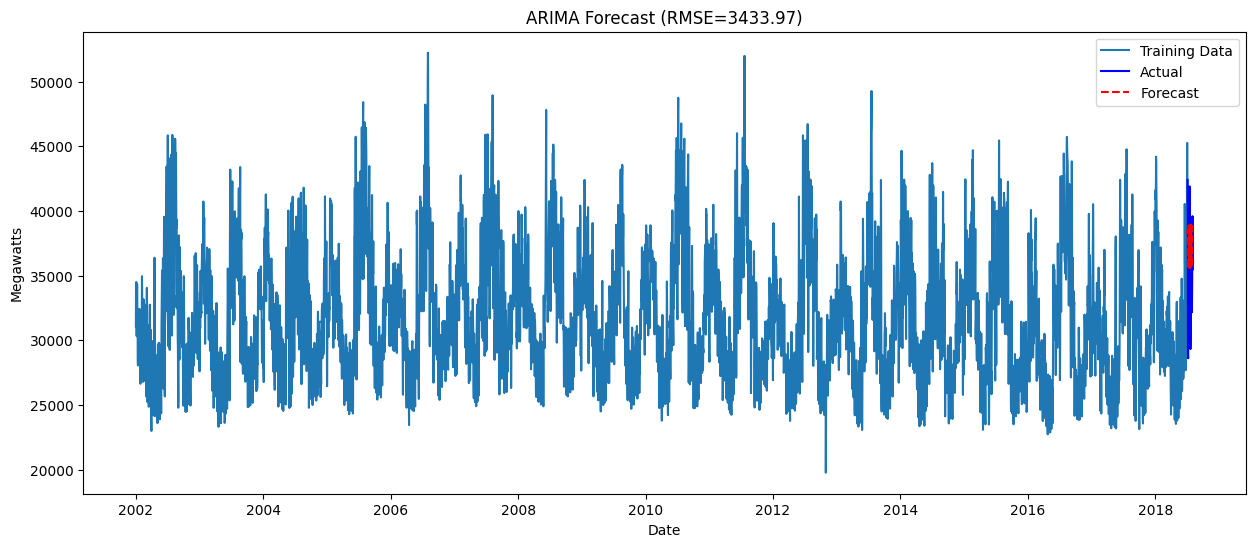

In [20]:
plt.figure(figsize=(15,6))

# Training data
plt.plot(train.index,
         train,
         label='Training Data')

# Actual values
plt.plot(test.index,
         test,
         label='Actual',
         color='blue')

# Forecast values
plt.plot(test.index,
         forecast,
         label='Forecast',
         color='red',
         linestyle='--')

plt.title(f"ARIMA Forecast (RMSE={rmse:.2f})")

plt.xlabel("Date")
plt.ylabel("Megawatts")

plt.legend()

plt.show()